# Phase 1 — EDA : ChestMNIST — Distribution des 14 pathologies thoraciques

**Objectif** : explorer le dataset ChestMNIST avant toute modélisation pour :
- Quantifier le déséquilibre de classes (justifie le choix de `pos_weight` dans la loss)
- Analyser les co-occurrences de pathologies (informe la stratégie multi-label)
- Calculer les statistiques de normalisation (mean/std pour les modèles pré-entraînés)
- Visualiser des exemples par classe

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du dossier racine au path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from src.setup_check import set_global_seeds
set_global_seeds(42)

print(f'Figures → {FIGURES_DIR}')

Figures → C:\Users\Pret Jeff\OneDrive - Efrei\Documents\Cours\Machine_learning_and_Deep_learning\Deep Learning project\triage-radiologique\reports\figures


## 1. Chargement de ChestMNIST

Le dataset est téléchargé automatiquement par `medmnist` au premier appel.

In [2]:
from medmnist import ChestMNIST

RESOLUTION = 64
DATA_DIR = str(ROOT / 'data' / 'raw' / 'chestmnist')

train_ds = ChestMNIST('train', size=RESOLUTION, download=True, root=DATA_DIR, as_rgb=True)
val_ds   = ChestMNIST('val',   size=RESOLUTION, download=True, root=DATA_DIR, as_rgb=True)
test_ds  = ChestMNIST('test',  size=RESOLUTION, download=True, root=DATA_DIR, as_rgb=True)

train_labels = train_ds.labels  # (N, 14)
val_labels   = val_ds.labels
test_labels  = test_ds.labels
all_labels   = np.vstack([train_labels, val_labels, test_labels])

LABEL_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
    'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
    'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia',
]

print(f'Train : {len(train_ds):,} | Val : {len(val_ds):,} | Test : {len(test_ds):,}')
print(f'Shape labels : {train_labels.shape}  (N, 14 classes binaires)')

Train : 78,468 | Val : 11,219 | Test : 22,433
Shape labels : (78468, 14)  (N, 14 classes binaires)


## 2. Distribution des labels — déséquilibre de classes

**Enjeu cours** : un fort déséquilibre rend l'accuracy brute non informative. On calcule
le `pos_weight[c] = nb_négatifs_c / nb_positifs_c` pour pondérer la `BCEWithLogitsLoss`.

C:\Users\Pret Jeff\AppData\Local\Temp\ipykernel_14040\935834343.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)


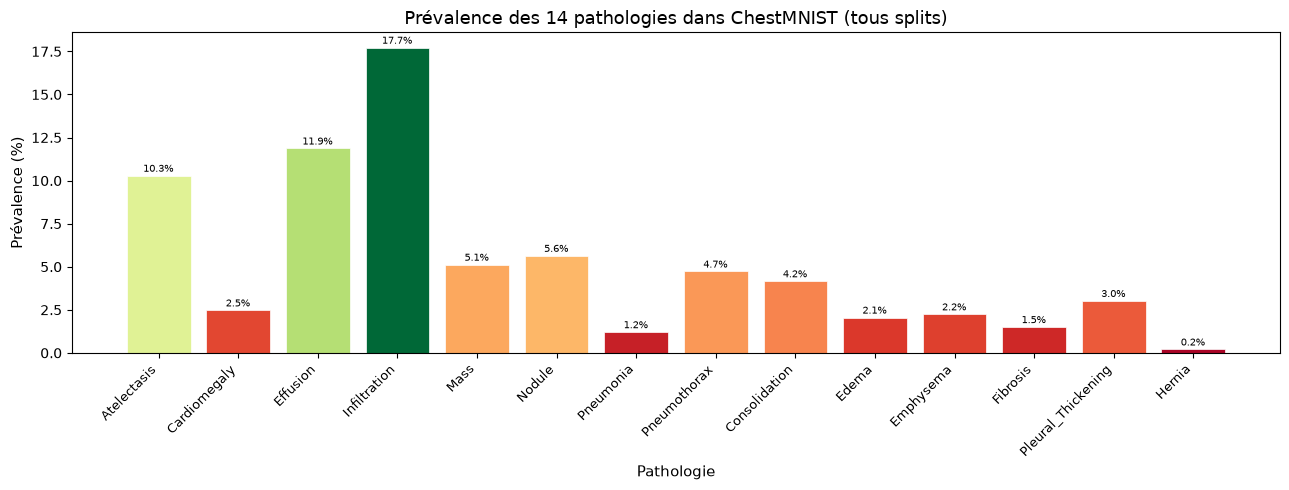

Prévalence par classe (tri décroissant) :
  Infiltration         : 17.72%  ████████
  Effusion             : 11.87%  █████
  Atelectasis          : 10.29%  █████
  Nodule               :  5.64%  ██
  Mass                 :  5.12%  ██
  Pneumothorax         :  4.73%  ██
  Consolidation        :  4.16%  ██
  Pleural_Thickening   :  3.02%  █
  Cardiomegaly         :  2.47%  █
  Emphysema            :  2.24%  █
  Edema                :  2.05%  █
  Fibrosis             :  1.50%  
  Pneumonia            :  1.21%  
  Hernia               :  0.20%  


In [3]:
n_pos   = all_labels.sum(axis=0)
n_total = len(all_labels)
prev    = 100 * n_pos / n_total

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.RdYlGn(prev / prev.max())
bars = ax.bar(LABEL_NAMES, prev, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Pathologie', fontsize=11)
ax.set_ylabel('Prévalence (%)', fontsize=11)
ax.set_title('Prévalence des 14 pathologies dans ChestMNIST (tous splits)', fontsize=13)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, prev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_label_distribution.png', dpi=150)
plt.show()

print('Prévalence par classe (tri décroissant) :')
for name, p in sorted(zip(LABEL_NAMES, prev), key=lambda x: -x[1]):
    bar = '█' * int(p / 2)
    print(f'  {name:20s} : {p:5.2f}%  {bar}')

In [4]:
# Calcul de pos_weight pour BCEWithLogitsLoss
n_pos_train = train_labels.sum(axis=0)
n_neg_train = len(train_labels) - n_pos_train
pos_weight  = n_neg_train / np.maximum(n_pos_train, 1)

print('pos_weight par classe (utilisé dans BCEWithLogitsLoss) :')
print('  Plus la classe est rare, plus son poids est élevé.\n')
for name, pw in sorted(zip(LABEL_NAMES, pos_weight), key=lambda x: -x[1]):
    print(f'  {name:20s} : {pw:6.1f}×')

pos_weight par classe (utilisé dans BCEWithLogitsLoss) :
  Plus la classe est rare, plus son poids est élevé.

  Hernia               :  543.9×
  Pneumonia            :   79.2×
  Fibrosis             :   66.8×
  Edema                :   45.4×
  Emphysema            :   42.6×
  Cardiomegaly         :   39.2×
  Pleural_Thickening   :   33.4×
  Consolidation        :   23.0×
  Pneumothorax         :   20.2×
  Mass                 :   18.7×
  Nodule               :   16.9×
  Atelectasis          :    8.8×
  Effusion             :    7.5×
  Infiltration         :    4.6×


## 3. Matrice de co-occurrences

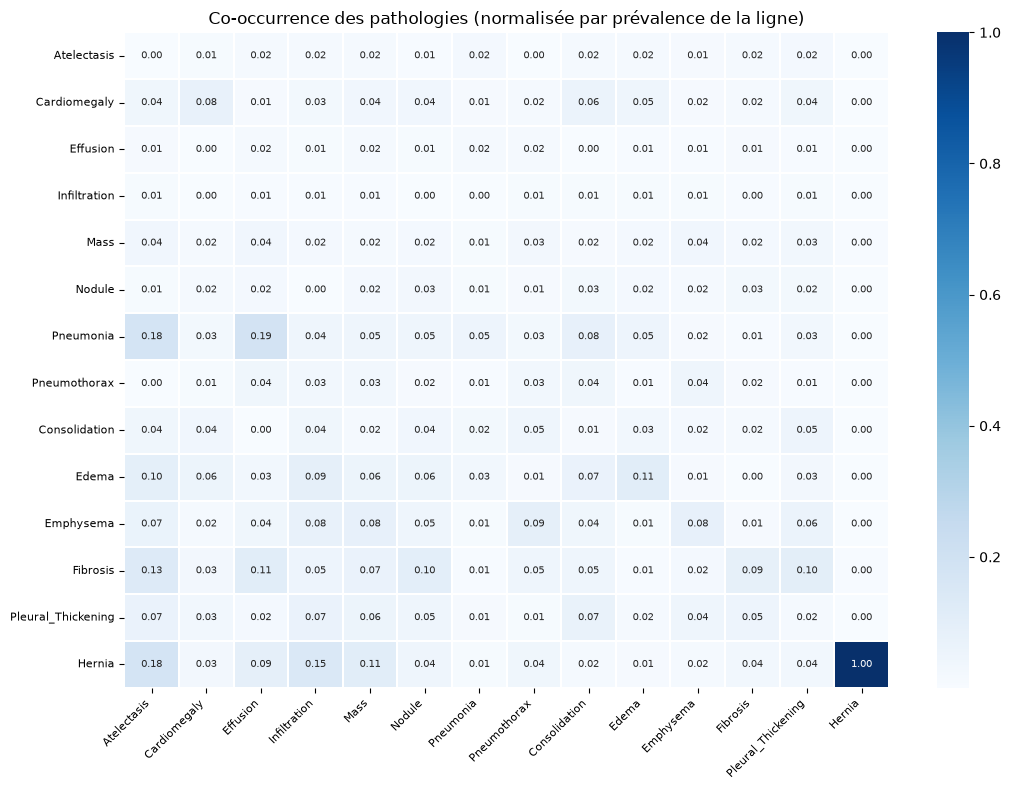

In [5]:
cooc      = all_labels.T @ all_labels
cooc_norm = cooc / (n_pos[:, None] + 1e-8)  # normalisé par la prévalence de chaque classe

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cooc_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax,
    linewidths=0.3, annot_kws={'size': 7}
)
ax.set_title('Co-occurrence des pathologies (normalisée par prévalence de la ligne)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_cooccurrence_matrix.png', dpi=150)
plt.show()

## 4. Distribution du nombre de labels par image

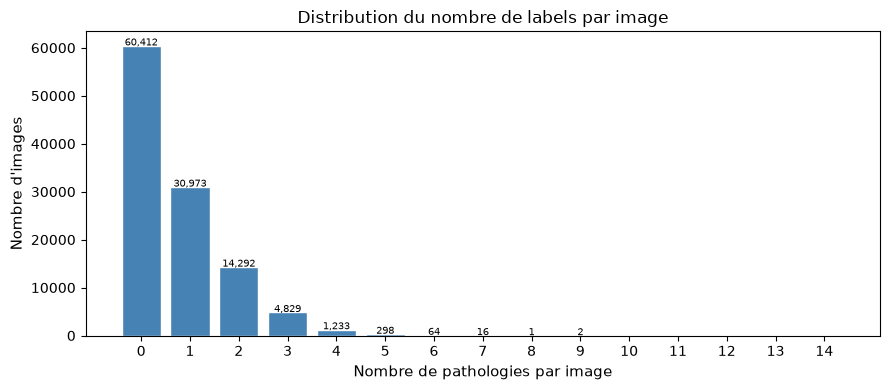

Images normales (0 pathologie)    : 53.9%  → utilisées pour entraîner l'AE/VAE
Images multi-label (≥2 pathologies): 18.5% → justifie le choix multi-label


In [6]:
n_labels_per_img = all_labels.sum(axis=1).astype(int)
counts = np.bincount(n_labels_per_img, minlength=15)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(15), counts, width=0.8, color='steelblue', edgecolor='white')
ax.set_xlabel('Nombre de pathologies par image', fontsize=11)
ax.set_ylabel('Nombre d\'images', fontsize=11)
ax.set_title('Distribution du nombre de labels par image', fontsize=12)
ax.set_xticks(range(15))
for x, cnt in enumerate(counts):
    if cnt > 0:
        ax.text(x, cnt + 80, f'{cnt:,}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_labels_per_image.png', dpi=150)
plt.show()

pct_normal   = 100 * (n_labels_per_img == 0).sum() / len(n_labels_per_img)
pct_multilbl = 100 * (n_labels_per_img > 1).sum() / len(n_labels_per_img)
print(f'Images normales (0 pathologie)    : {pct_normal:.1f}%  → utilisées pour entraîner l\'AE/VAE')
print(f'Images multi-label (≥2 pathologies): {pct_multilbl:.1f}% → justifie le choix multi-label')

## 5. Exemples visuels par pathologie

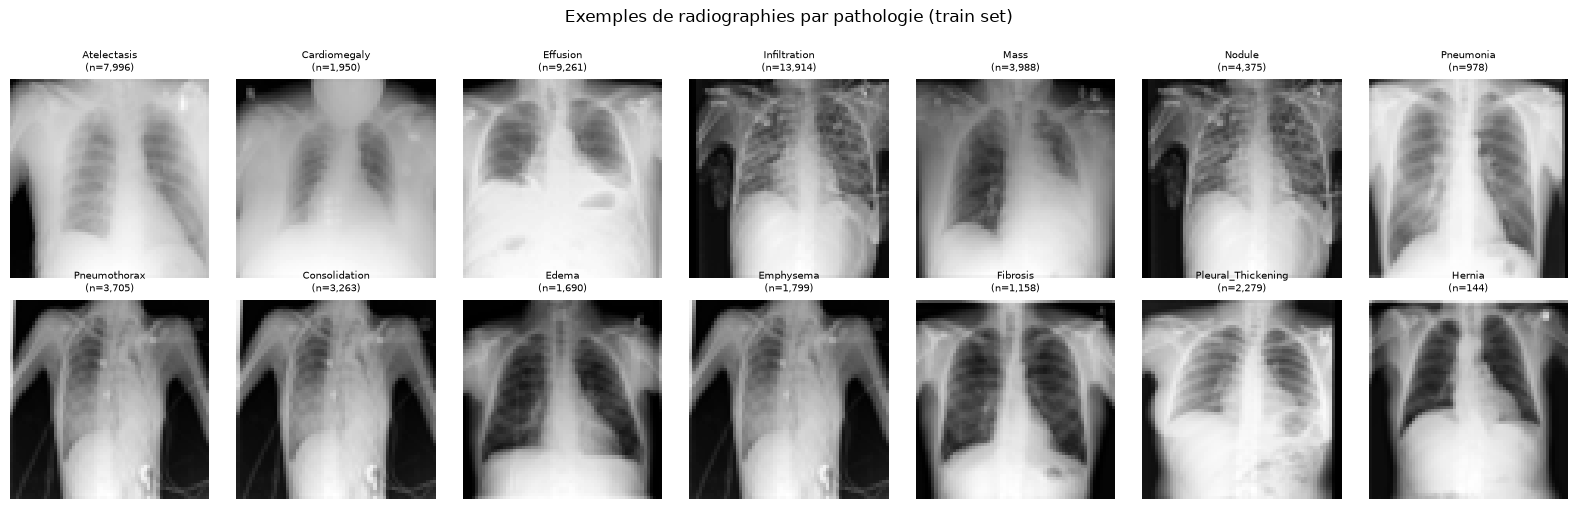

In [7]:
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
axes = axes.flatten()

for c, label in enumerate(LABEL_NAMES):
    pos_idx = np.where(train_labels[:, c] == 1)[0]
    if len(pos_idx) > 0:
        img = train_ds.imgs[pos_idx[0]]  # (H, W) ou (H, W, 3)
        cmap = 'gray' if img.ndim == 2 else None
        axes[c].imshow(img, cmap=cmap)
        axes[c].set_title(f'{label}\n(n={len(pos_idx):,})', fontsize=7.5)
    else:
        axes[c].text(0.5, 0.5, 'Absent', ha='center', va='center', transform=axes[c].transAxes)
    axes[c].axis('off')

fig.suptitle('Exemples de radiographies par pathologie (train set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_examples_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Statistiques des pixels — paramètres de normalisation

Statistiques des pixels ChestMNIST (train) :
  Moyenne (RGB) : [0.4976 0.4976 0.4976]
  Ecart-type    : [0.2423 0.2423 0.2423]

Reference ImageNet : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
-> Valeurs proches -> la normalisation ImageNet est appropriee pour le transfer learning.


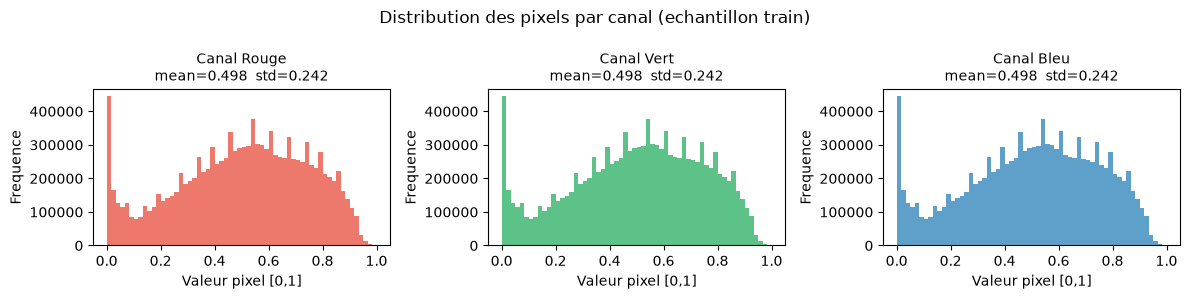

In [8]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(train_ds), min(3000, len(train_ds)), replace=False)
pixel_data = train_ds.imgs[sample_idx].astype(np.float32) / 255.0

# medmnist 3.x retourne (N, H, W) grayscale même avec as_rgb=True → expand en (N, H, W, 3)
if pixel_data.ndim == 3:
    pixel_data = np.stack([pixel_data] * 3, axis=-1)

mean_ch = pixel_data.mean(axis=(0, 1, 2))
std_ch  = pixel_data.std(axis=(0, 1, 2))

print('Statistiques des pixels ChestMNIST (train) :')
print(f'  Moyenne (RGB) : {mean_ch.round(4)}')
print(f'  Ecart-type    : {std_ch.round(4)}')
print(f'\nReference ImageNet : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]')
print('-> Valeurs proches -> la normalisation ImageNet est appropriee pour le transfer learning.')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
colors   = ['#e74c3c', '#27ae60', '#2980b9']
channels = ['Rouge', 'Vert', 'Bleu']
for c, (color, name) in enumerate(zip(colors, channels)):
    axes[c].hist(pixel_data[:, :, :, c].flatten(), bins=60, color=color, alpha=0.75, edgecolor='none')
    axes[c].set_title(f'Canal {name}\nmean={mean_ch[c]:.3f}  std={std_ch[c]:.3f}', fontsize=10)
    axes[c].set_xlabel('Valeur pixel [0,1]')
    axes[c].set_ylabel('Frequence')
fig.suptitle('Distribution des pixels par canal (echantillon train)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_pixel_distribution.png', dpi=150)
plt.show()

## 7. Résumé EDA — constats clés

In [9]:
print('=' * 60)
print('RÉSUMÉ EDA — Constats clés pour la modélisation')
print('=' * 60)
print(f'\n1. DÉSÉQUILIBRE : la classe la plus fréquente ({LABEL_NAMES[int(prev.argmax())]})')
print(f'   a une prévalence de {prev.max():.1f}% vs {prev.min():.1f}% pour la plus rare ({LABEL_NAMES[int(prev.argmin())]})')
print(f'   → pos_weight max = {pos_weight.max():.0f}× → BCEWithLogitsLoss pondérée obligatoire')
print(f'\n2. MULTI-LABEL : {pct_multilbl:.1f}% des images ont ≥2 pathologies simultanées')
print(f'   → architecture multi-label avec sigmoïde par classe (pas softmax)')
print(f'\n3. NORMAUX : {pct_normal:.1f}% des images sans pathologie')
print(f'   → base d\'entraînement pour l\'AE/VAE (détection d\'anomalie)')
print(f'\n4. NORMALISATION : mean ChestMNIST ≈ ImageNet → normalisation ImageNet valide')
print(f'\n5. MÉTRIQUES : accuracy brute inadaptée → F1 macro, MCC, AUC par classe')
print(f'\n✓ Figures sauvegardées dans : reports/figures/')

RÉSUMÉ EDA — Constats clés pour la modélisation

1. DÉSÉQUILIBRE : la classe la plus fréquente (Infiltration)
   a une prévalence de 17.7% vs 0.2% pour la plus rare (Hernia)
   → pos_weight max = 544× → BCEWithLogitsLoss pondérée obligatoire

2. MULTI-LABEL : 18.5% des images ont ≥2 pathologies simultanées
   → architecture multi-label avec sigmoïde par classe (pas softmax)

3. NORMAUX : 53.9% des images sans pathologie
   → base d'entraînement pour l'AE/VAE (détection d'anomalie)

4. NORMALISATION : mean ChestMNIST ≈ ImageNet → normalisation ImageNet valide

5. MÉTRIQUES : accuracy brute inadaptée → F1 macro, MCC, AUC par classe

✓ Figures sauvegardées dans : reports/figures/
